In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from ucimlrepo import fetch_ucirepo 


In [2]:
plt.rcParams['figure.dpi'] = 300

In [3]:

# fetch dataset 
predict_students_dropout_and_academic_success = fetch_ucirepo(id=697) 
  
# # data (as pandas dataframes) 
X = predict_students_dropout_and_academic_success.data.features 
Y = predict_students_dropout_and_academic_success.data.targets 
  
# # metadata 
# print(predict_students_dropout_and_academic_success.metadata) 
  
# variable information 
dfvar = predict_students_dropout_and_academic_success.variables


In [4]:
dfvar

,name,role,type,demographic,description,units,missing_values
0,Marital Status,Feature,Integer,Marital Status,1 – single 2 – married 3 – widower 4 – divorce...,None,no
1,Application mode,Feature,Integer,None,1 - 1st phase - general contingent 2 - Ordinan...,None,no
2,Application order,Feature,Integer,None,Application order (between 0 - first choice; a...,None,no
3,Course,Feature,Integer,None,33 - Biofuel Production Technologies 171 - Ani...,None,no
4,Daytime/evening attendance,Feature,Integer,None,1 – daytime 0 - evening,None,no
5,Previous qualification,Feature,Integer,Education Level,1 - Secondary education 2 - Higher education -...,None,no
6,Previous qualification (grade),Feature,Continuous,None,Grade of previous qualification (between 0 and...,None,no
7,Nacionality,Feature,Integer,Nationality,1 - Portuguese; 2 - German; 6 - Spanish; 11 - ...,None,no
8,Mother's qualification,Feature,Integer,Education Level,1 - Secondary Education - 12th Year of Schooli...,None,no
9,Father's qualification,Feature,Integer,Education Level,1 - Secondary Education - 12th Year of Schooli...,None,no


In [5]:
## Split variables based on type. Each variable type gets a different scaling treatment.

# Nominal categorical and binary variables (Apply one-hot encoding)
onehot_cols = [
    'Marital Status',
    'Application mode',
    'Course',
    'Nacionality',
    "Mother's occupation",
    "Father's occupation",
    'Daytime/evening attendance',
    'Displaced',
    'Educational special needs',
    'Debtor',
    'Tuition fees up to date',
    'Gender',
    'Scholarship holder',
    'International'
]

# Ordinal categorical and continuous variables (Apply Z-score normalization)
scale_cols = [
    'Previous qualification',
    "Mother's qualification",
    "Father's qualification",
    'Application order',
    'Age at enrollment',
    'Previous qualification (grade)',
    'Admission grade',
    'Curricular units 1st sem (credited)',
    'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (credited)',
    'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (without evaluations)',
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (grade)',
    'Unemployment rate',
    'Inflation rate',
    'GDP'
]

In [6]:
column_transformer = ColumnTransformer(transformers=[
    ('onehot', OneHotEncoder(drop='if_binary', handle_unknown='ignore', sparse_output=False), onehot_cols),
    ('scale', StandardScaler(), scale_cols)
])

recoded_data = column_transformer.fit_transform(X)

In [7]:
feature_names = column_transformer.get_feature_names_out()
X_transformed = pd.DataFrame(recoded_data, columns=feature_names)

In [8]:
X_transformed

,onehot__Marital Status_1,onehot__Marital Status_2,onehot__Marital Status_3,onehot__Marital Status_4,onehot__Marital Status_5,onehot__Marital Status_6,onehot__Application mode_1,onehot__Application mode_2,onehot__Application mode_5,onehot__Application mode_7,...,scale__Curricular units 2nd sem (credited),scale__Curricular units 2nd sem (enrolled),scale__Curricular units 2nd sem (evaluations),scale__Curricular units 2nd sem (approved),scale__Curricular units 2nd sem (without evaluations),scale__Curricular units 1st sem (grade),scale__Curricular units 2nd sem (grade),scale__Unemployment rate,scale__Inflation rate,scale__GDP
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.282442,-2.838337,-2.042630,-1.471527,-0.199441,-2.197102,-1.963489,-0.287638,0.124386,0.765761
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.282442,-0.105726,-0.522682,0.518904,-0.199441,0.693599,0.659562,0.876222,-1.105222,0.347199
2,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,-0.282442,-0.105726,-2.042630,-1.471527,-0.199441,-2.197102,-1.963489,-0.287638,0.124386,0.765761
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.282442,-0.105726,0.490616,0.187165,-0.199441,0.575611,0.416450,-0.813253,-1.466871,-1.375511
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.282442,-0.105726,-0.522682,0.518904,-0.199441,0.349468,0.531608,0.876222,-1.105222,0.347199
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,-0.282442,-0.105726,-0.016033,0.187165,-0.199441,0.611007,0.467631,1.476924,1.137005,-1.789667
4420,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,-0.282442,-0.105726,-0.522682,-0.808050,-0.199441,0.280641,0.147747,-0.175007,-0.454253,0.889126
4421,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,-0.282442,0.805144,0.237291,-1.139788,-0.199441,0.882010,0.627573,0.876222,-1.105222,0.347199
4422,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,-0.282442,-0.561161,-0.522682,0.187165,-0.199441,0.652303,0.339678,-0.813253,-1.466871,-1.375511


In [9]:
pca = PCA()
pca_transformed_x_1 = pca.fit_transform(recoded_data)

Text(45, 0.7, '95% variance at 40 components')

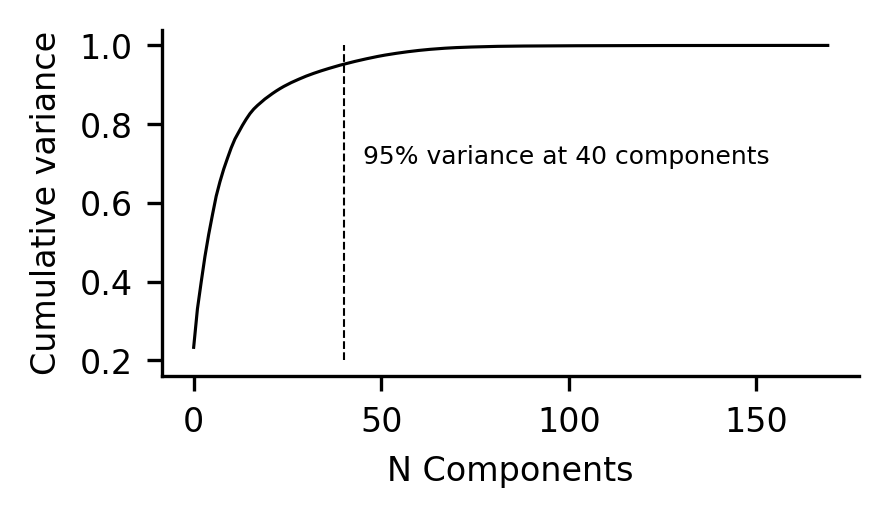

In [10]:
fig, ax = plt.subplots(figsize = (3,1.5))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
cutoff_95 = np.where(cumulative_variance>0.95)[0][0]

ax.tick_params(labelsize = 8)
ax.plot(cumulative_variance, linewidth = 0.75, color = 'black')
ax.set_xlabel("N Components", fontsize = 8)
ax.set_ylabel("Cumulative variance", fontsize = 8)
ax.plot([cutoff_95]*100, np.linspace(0.2,1,100), '--', linewidth = 0.5, color = 'black')
ax.text(cutoff_95+5, 0.7, f'95% variance at {cutoff_95} components', fontsize = 6)

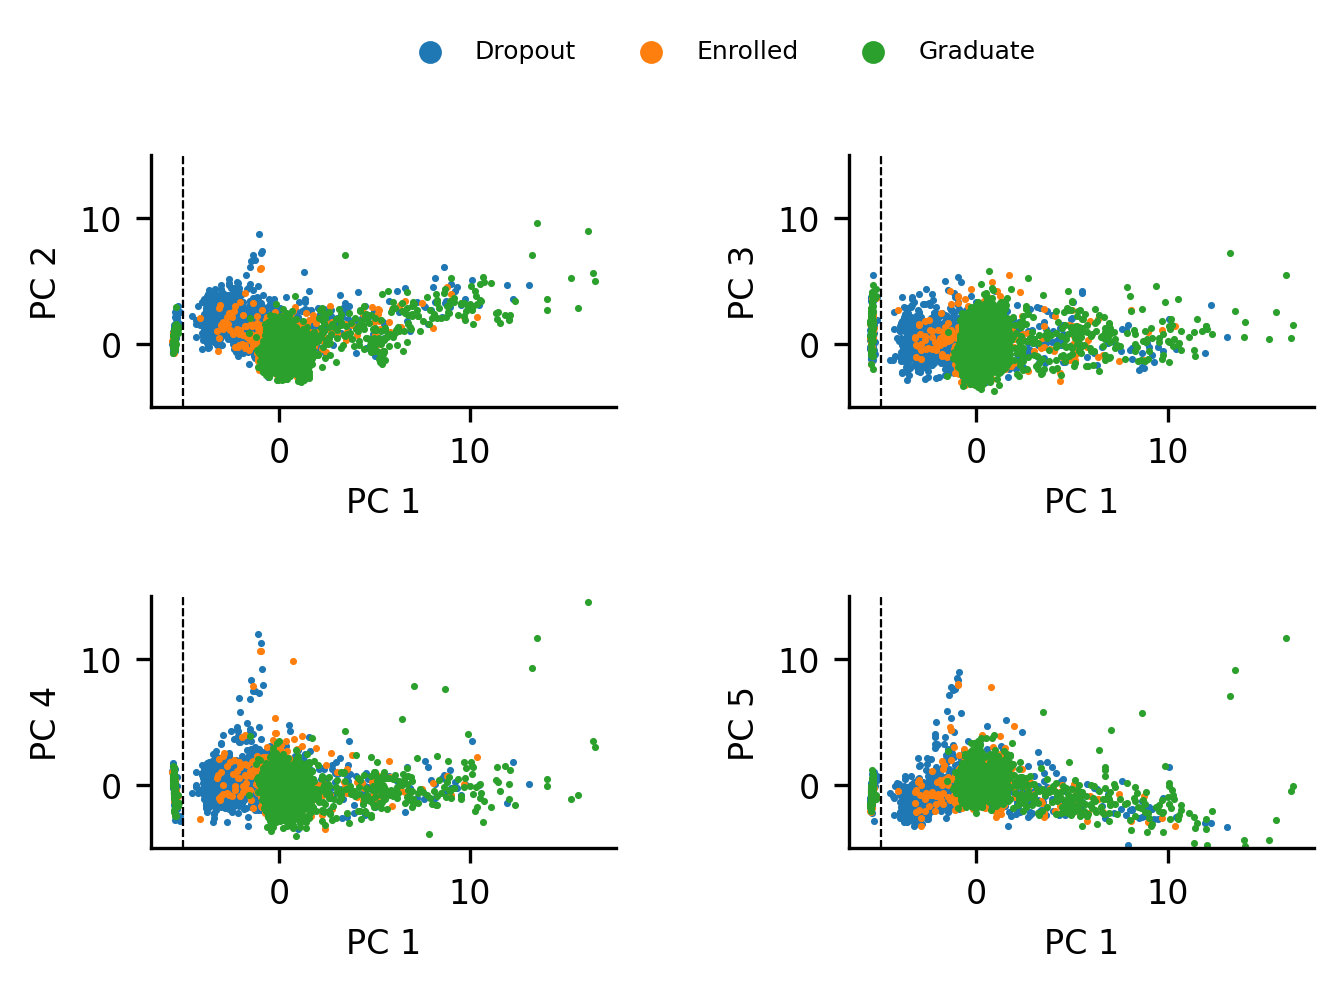

In [11]:
fig, ax = plt.subplots(2,2, figsize = (5,3))

fontsize = 8
categories = np.unique(Y.values)
labels = [np.where(Y.values[:,0] == categories[i])[0] for i in range(3)]
comp_pairs = (list(combinations(np.arange(10), 2)))
i = 0
for row in range(2):
    for col in range(2):
        for z, cat in enumerate(labels):
            ax[row, col].spines['top'].set_visible(False)
            ax[row, col].spines['right'].set_visible(False)
            ax[row, col].tick_params(labelsize = fontsize)

            c0, c1 = comp_pairs[i]
            ax[row, col].scatter(pca_transformed_x_1[cat,c0], pca_transformed_x_1[cat,c1], s = 0.5, label = np.unique(Y.values)[z]) 
            ax[row, col].set_xlabel(f"PC {c0+1}", fontsize = 8)
            ax[row, col].set_ylabel(f"PC {c1+1}", fontsize = 8)
            ax[row, col].plot([-5]*100, np.linspace(-5,15,100), '--', linewidth = 0.5, color = 'black')
            ax[row, col].set_ylim(-5,15)

        i+=1

fig.subplots_adjust(hspace = 0.75, wspace = .5)
lgnd = ax[0,0].legend(fontsize = 6, bbox_to_anchor = (1.95,1.55), frameon = False, ncol = 3)
for handle in lgnd.legend_handles:
    handle.set_sizes([20.0]) 

In [12]:
anomalous_samples = np.where(pca_transformed_x_1[:,0]<-5)[0]

In [13]:
X.iloc[anomalous_samples]

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0,0.0,0,10.8,1.4,1.74
20,1,1,3,171,1,1,122.0,1,1,1,...,0,0,0,0,0,0.0,0,11.1,0.6,2.02
59,1,1,3,171,1,1,125.0,1,38,37,...,0,0,0,0,0,0.0,0,7.6,2.6,0.32
62,1,17,3,171,1,1,133.0,1,1,37,...,0,0,0,0,0,0.0,0,10.8,1.4,1.74
66,1,1,3,171,1,1,139.0,1,19,19,...,0,0,0,0,0,0.0,0,10.8,1.4,1.74
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4308,1,44,1,171,1,39,110.0,1,1,1,...,0,0,0,0,0,0.0,0,12.4,0.5,1.79
4331,1,17,1,171,1,1,145.0,1,37,19,...,0,0,0,0,0,0.0,0,11.1,0.6,2.02
4353,1,1,1,171,1,1,141.0,1,3,1,...,0,0,0,0,0,0.0,0,12.4,0.5,1.79
4365,1,1,2,171,1,1,117.0,1,38,38,...,0,0,0,0,0,0.0,0,7.6,2.6,0.32


In [14]:
top_pc_ind = np.where(pca.components_[0]>0.2)[0]
pc1_top_loading_t = list(X_transformed.columns[top_pc_ind])
pc1_top_loading = [x.replace('scale__', '') for x in pc1_top_loading_t]

In [15]:
X.iloc[anomalous_samples][pc1_top_loading].sum()

Curricular units 1st sem (credited)       0.0
Curricular units 1st sem (enrolled)       0.0
Curricular units 1st sem (evaluations)    0.0
Curricular units 1st sem (approved)       0.0
Curricular units 2nd sem (credited)       0.0
Curricular units 2nd sem (enrolled)       0.0
Curricular units 2nd sem (evaluations)    0.0
Curricular units 2nd sem (approved)       0.0
Curricular units 1st sem (grade)          0.0
Curricular units 2nd sem (grade)          0.0
dtype: float64

In [16]:
Y_exp = Y.copy()
Y_exp['_'] = np.ones(len(Y_exp))
Y_exp.iloc[anomalous_samples].groupby('Target').agg('sum')

,_
Target,
Dropout,77.0
Enrolled,28.0
Graduate,75.0


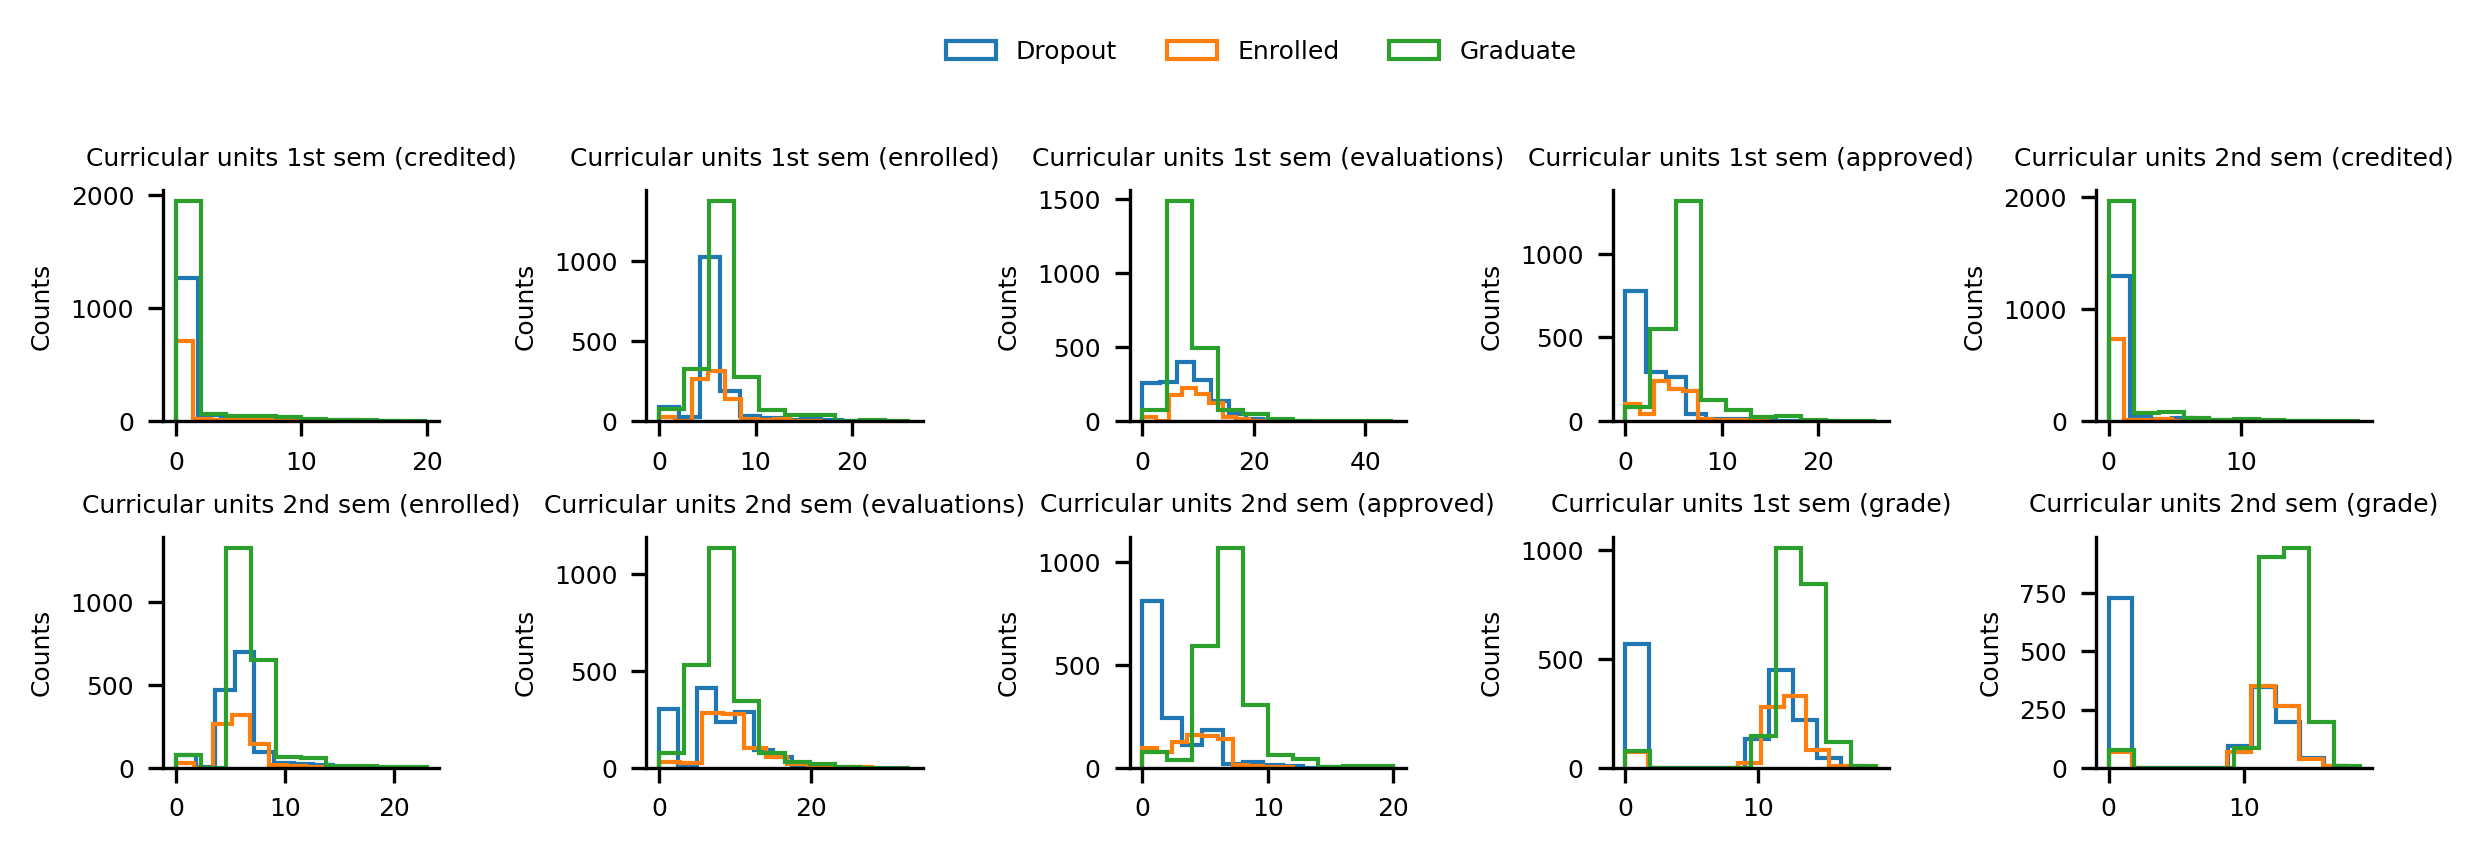

In [17]:
fig, ax = plt.subplots(2,5, figsize = (9.5,2.5))

#labe
i = 0
for row in range(2):
    for col in range(5):
        ax[row, col].spines['top'].set_visible(False)
        ax[row, col].spines['right'].set_visible(False)
        ax[row, col].tick_params(labelsize = 6)
        ax[row, col].hist(X[pc1_top_loading[i]].values[labels[0]], bins = 10, histtype='step', label = categories[0])
        ax[row, col].hist(X[pc1_top_loading[i]].values[labels[1]], bins = 10, histtype='step', label = categories[1])
        ax[row, col].hist(X[pc1_top_loading[i]].values[labels[2]], bins = 10, histtype='step', label = categories[2])
        ax[row, col].set_title(pc1_top_loading[i], fontsize = 6)
        ax[row, col].set_ylabel("Counts", fontsize = 6)
        i+=1

lgnd = ax[0,0].legend(fontsize = 6, bbox_to_anchor = (5.2,1.75), frameon = False, ncol = 3)
fig.subplots_adjust(hspace=0.5, wspace=0.75)
# for handle in lgnd.legend_handles:
#     #handle.set_sizes([20.0]) 

In [18]:
anomolous_variables = ['Curricular units 1st sem (credited)', 'Curricular units 2nd sem (credited)']

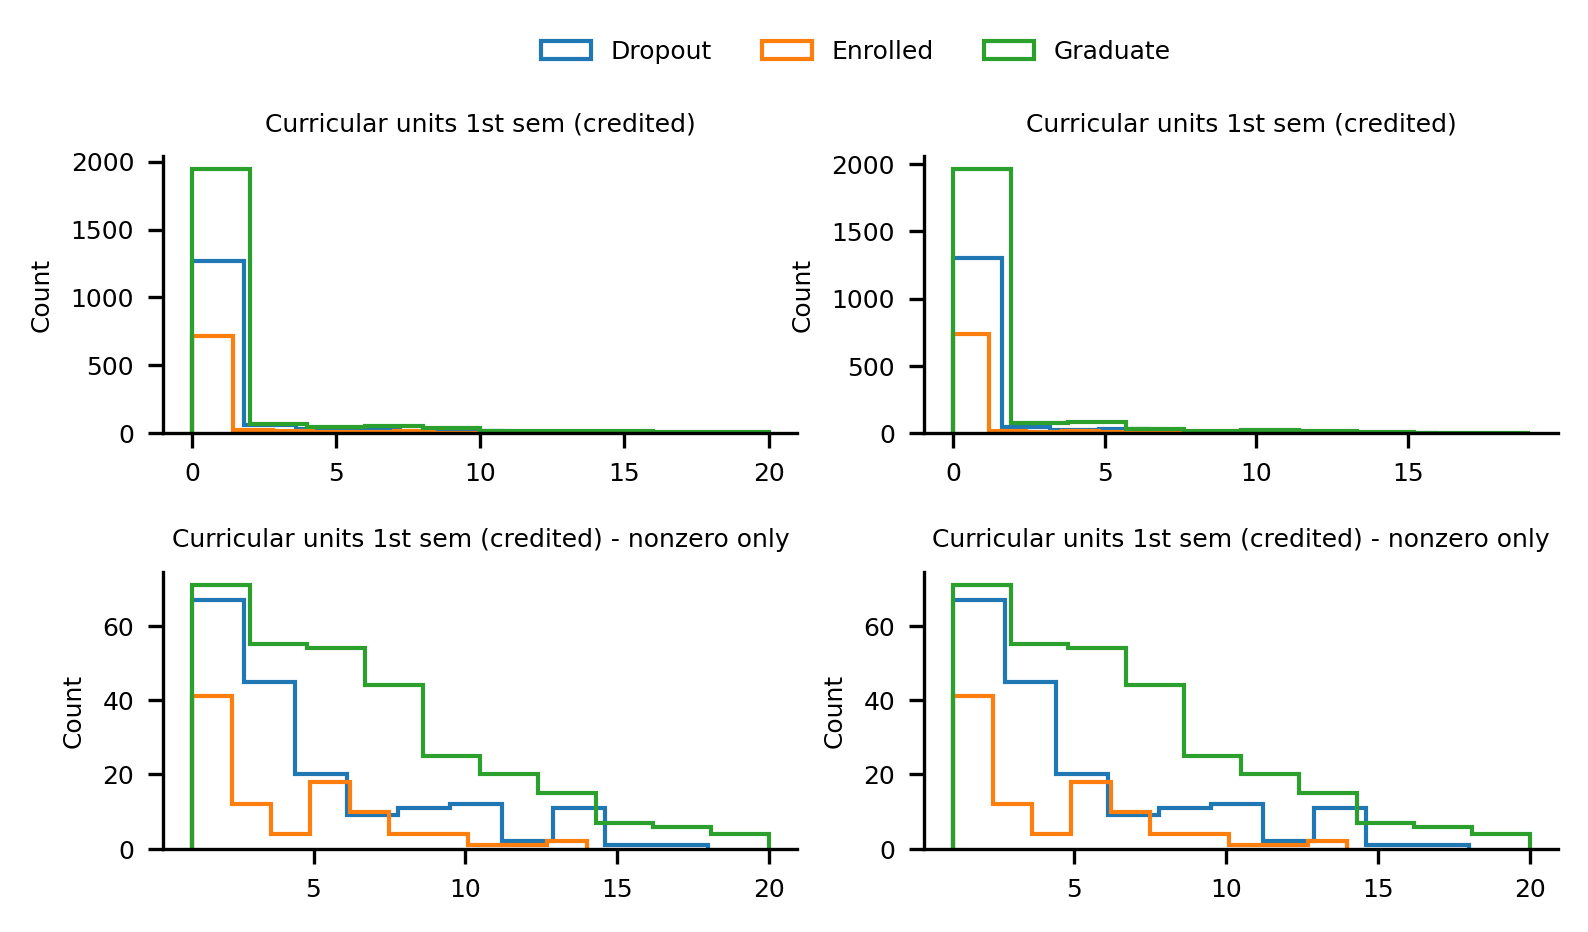

In [19]:
fig, ax = plt.subplots(2,2, figsize = (6,3))

i = 0
av1 = X[anomolous_variables[0]].values
av2 = X[anomolous_variables[0]].values

av1[np.where(av1>0)[0]]
av2[np.where(av2>0)[0]]

avnonzero = [av1, av2]
for col in range(2):
    for row in range(2):
        ax[row, col].spines['top'].set_visible(False)
        ax[row, col].spines['right'].set_visible(False)
        ax[row, col].tick_params(labelsize = 6)
        ax[row, col].set_ylabel("Count", fontsize = 6)

    ax[0, col].hist(X[anomolous_variables[i]][labels[0]], bins = 10, histtype='step', label = categories[0])
    ax[0, col].hist(X[anomolous_variables[i]][labels[1]], bins = 10, histtype='step', label = categories[1])
    ax[0, col].hist(X[anomolous_variables[i]][labels[2]], bins = 10, histtype='step', label = categories[2])


    av = X[anomolous_variables[0]].values
    av[labels[0]][np.where(av[labels[0]]>0)[0]]

    ax[1, col].hist(av[labels[0]][np.where(av[labels[0]]>0)[0]], bins = 10, histtype='step', label = categories[0])
    ax[1, col].hist(av[labels[1]][np.where(av[labels[1]]>0)[0]], bins = 10, histtype='step', label = categories[1])
    ax[1, col].hist(av[labels[2]][np.where(av[labels[2]]>0)[0]], bins = 10, histtype='step', label = categories[2])

    ax[0, col].set_title(anomolous_variables[0], fontsize = 6)
    ax[1, col].set_title(f"{anomolous_variables[0]} - nonzero only", fontsize = 6)
        
    i+=1
lgnd = ax[0,0].legend(fontsize = 6, bbox_to_anchor = (1.625,1.5), frameon = False, ncol = 3)
fig.subplots_adjust(hspace=0.5)

In [20]:
am = dfvar.loc[
    dfvar.name == 'Application mode'
].description.values[0]

In [21]:
## Get the application mode labels using regex
import re
r = r' ?\d{1,2} - '
matches = [(m.start(0), m.end(0)) for m in re.finditer(r, am)]
am_i = list(zip(matches[:-1], matches[1:]))
am_i = [(i[0][-1], i[1][0]) for i in am_i]
am_labels = [am[i[0]:i[1]] for i in am_i]
am_labels

['1st phase - general contingent',
 'Ordinance No. 612/93',
 '1st phase - special contingent (Azores Island)',
 'Holders of other higher courses',
 'Ordinance No. 854-B/99',
 'International student (bachelor)',
 '1st phase - special contingent (Madeira Island)',
 '2nd phase - general contingent',
 '3rd phase - general contingent',
 'Ordinance No. 533-A/99, item b2) (Different Plan)',
 'Ordinance No. 533-A/99, item b3 (Other Institution)',
 'Over 23 years old',
 'Transfer',
 'Change of course',
 'Technological specialization diploma holders',
 'Change of institution/course',
 'Short cycle diploma holders']

C:\Users\Sturdy\AppData\Local\Temp\ipykernel_33448\862390214.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(am_labels, rotation = 45, fontsize = 6, ha = 'right')


Text(0, 0.5, 'Count')

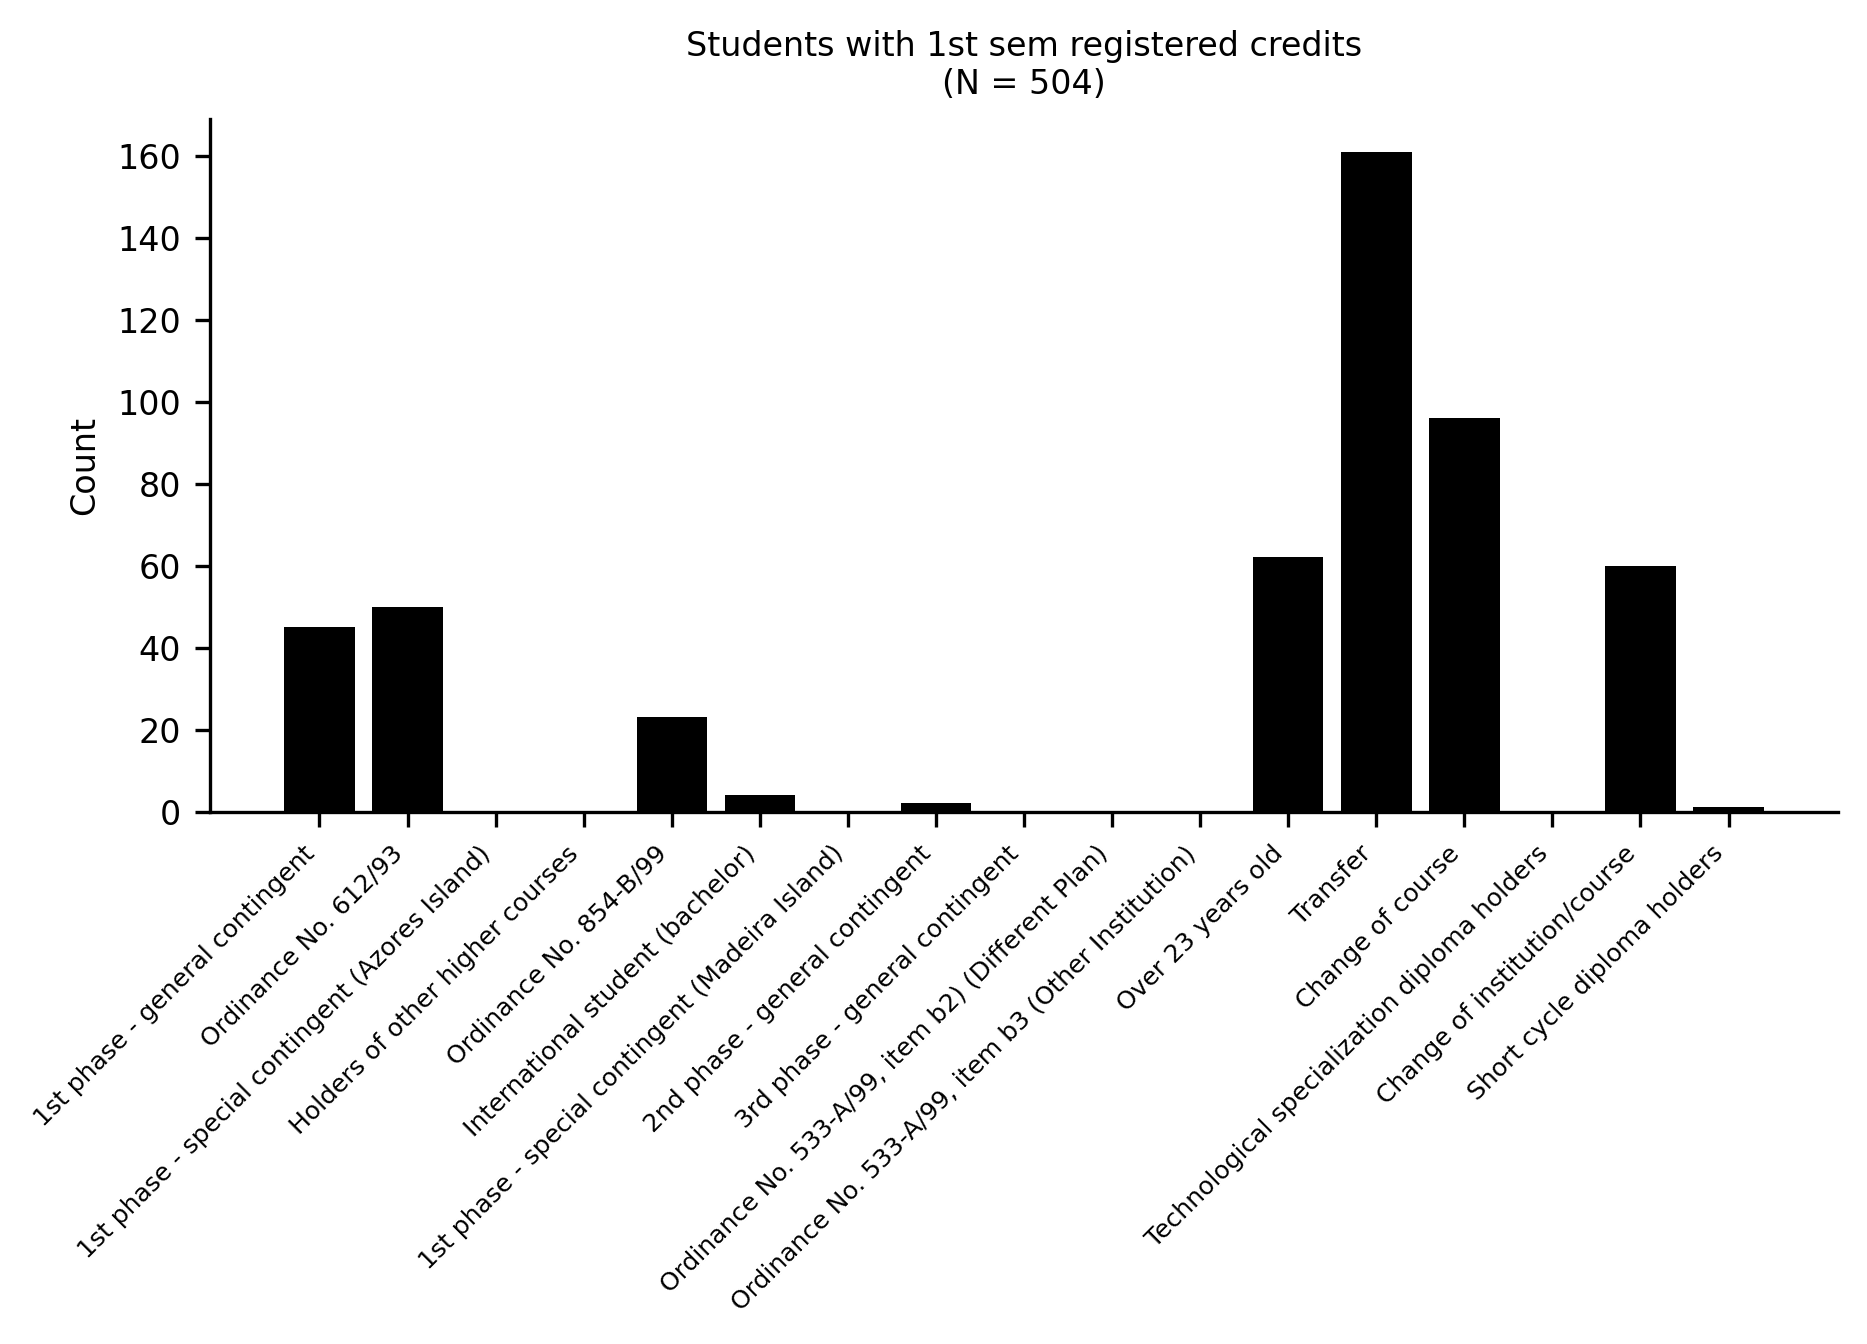

In [22]:
fig, ax = plt.subplots(figsize = (7, 3))

val = X.loc[
    (X[anomolous_variables[0]]>0)
    & (X[anomolous_variables[1]]>0)
]['Application mode'].values

h, bins = np.histogram(val, bins=17)
bin_centers = (h[:-1]+h[1:])/2
h.shape

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(labelsize = 8)
ax.bar(am_labels, h, color = 'black')
ax.set_xticklabels(am_labels, rotation = 45, fontsize = 6, ha = 'right')
ax.set_title(f"Students with 1st sem registered credits\n(N = {len(val)})", fontsize = 8)
ax.set_ylabel("Count", fontsize = 8)

In [23]:
pc160 = np.where(pca.components_[0]<0.2)[0]

In [24]:
pca = PCA()
pca_transformed_x_2 = pca.fit_transform(recoded_data[:,pc160])

Text(45, 0.7, '95% variance at 40 components')

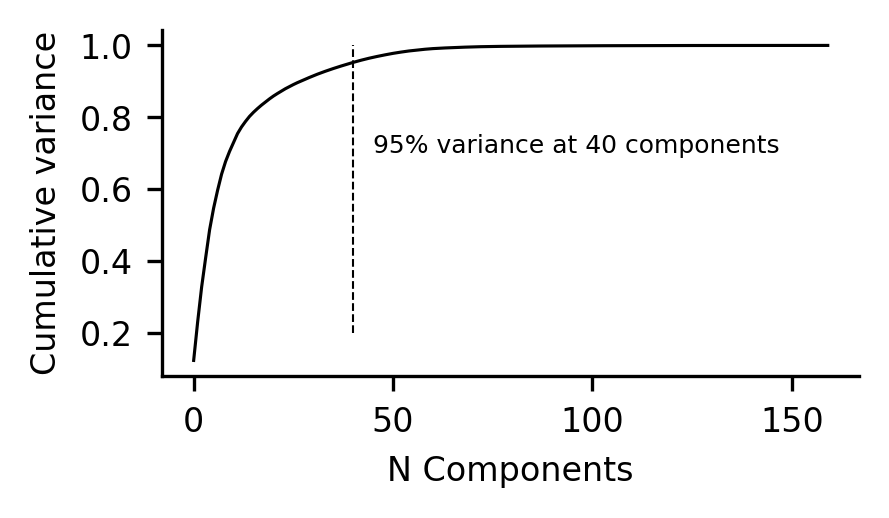

In [25]:
fig, ax = plt.subplots(figsize = (3,1.5))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
cutoff_95 = np.where(cumulative_variance>0.95)[0][0]

ax.tick_params(labelsize = 8)
ax.plot(cumulative_variance, linewidth = 0.75, color = 'black')
ax.set_xlabel("N Components", fontsize = 8)
ax.set_ylabel("Cumulative variance", fontsize = 8)
ax.plot([cutoff_95]*100, np.linspace(0.2,1,100), '--', linewidth = 0.5, color = 'black')
ax.text(cutoff_95+5, 0.7, f'95% variance at {cutoff_95} components', fontsize = 6)

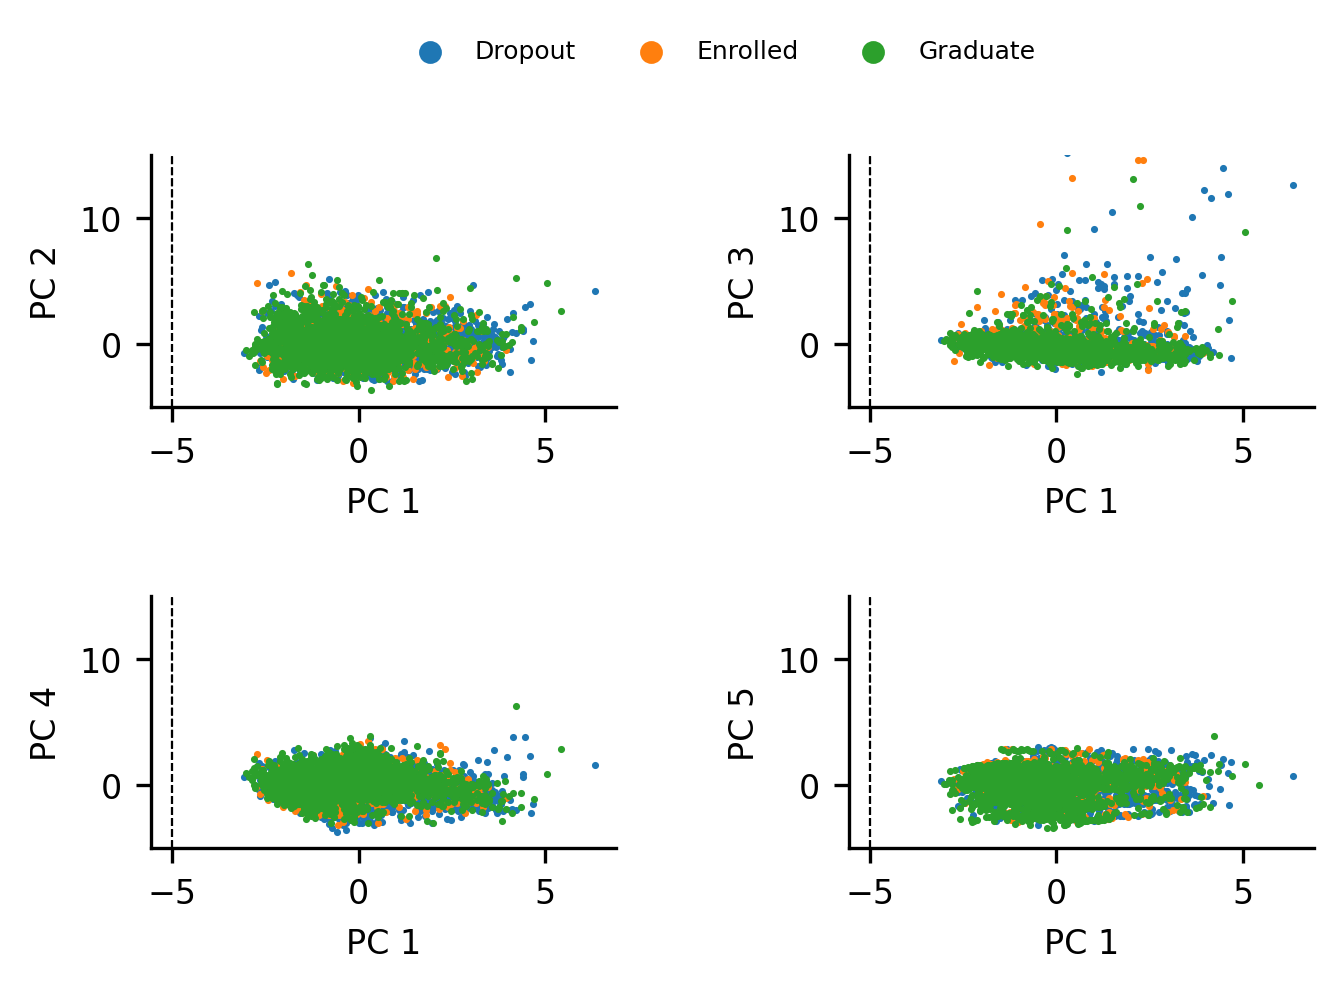

In [26]:
fig, ax = plt.subplots(2,2, figsize = (5,3))

fontsize = 8
categories = np.unique(Y.values)
labels = [np.where(Y.values[:,0] == categories[i])[0] for i in range(3)]
comp_pairs = (list(combinations(np.arange(10), 2)))
i = 0
for row in range(2):
    for col in range(2):
        for z, cat in enumerate(labels):
            ax[row, col].spines['top'].set_visible(False)
            ax[row, col].spines['right'].set_visible(False)
            ax[row, col].tick_params(labelsize = fontsize)

            c0, c1 = comp_pairs[i]
            ax[row, col].scatter(pca_transformed_x_2[cat,c0], pca_transformed_x_2[cat,c1], s = 0.5, label = np.unique(Y.values)[z]) 
            ax[row, col].set_xlabel(f"PC {c0+1}", fontsize = 8)
            ax[row, col].set_ylabel(f"PC {c1+1}", fontsize = 8)
            ax[row, col].plot([-5]*100, np.linspace(-5,15,100), '--', linewidth = 0.5, color = 'black')
            ax[row, col].set_ylim(-5,15)

        i+=1

fig.subplots_adjust(hspace = 0.75, wspace = .5)
lgnd = ax[0,0].legend(fontsize = 6, bbox_to_anchor = (1.95,1.55), frameon = False, ncol = 3)
for handle in lgnd.legend_handles:
    handle.set_sizes([20.0]) 

In [27]:
pca = PCA()
pca_transformed_x_3 = pca.fit_transform(recoded_data[:,top_pc_ind])

Text(5, 0.7, '95% variance at 4 components')

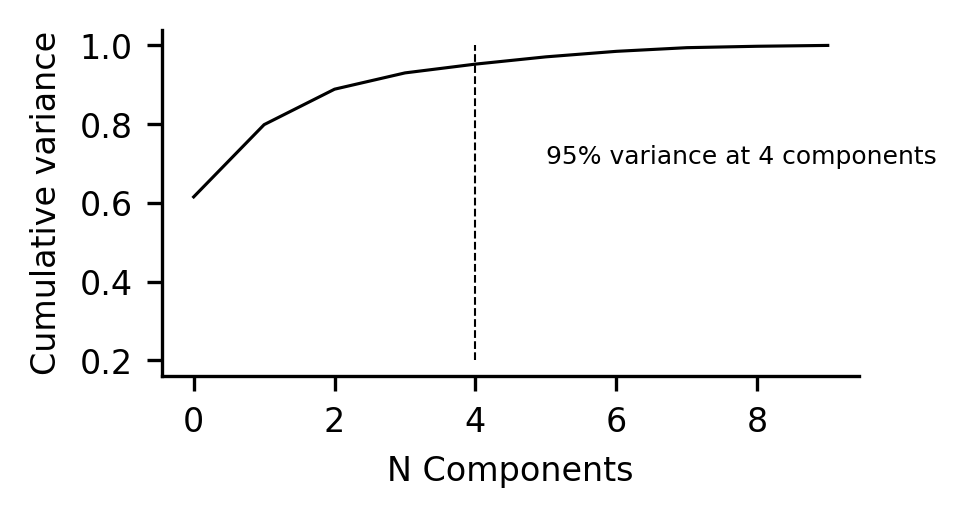

In [28]:
fig, ax = plt.subplots(figsize = (3,1.5))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
cutoff_95 = np.where(cumulative_variance>0.95)[0][0]

ax.tick_params(labelsize = 8)
ax.plot(cumulative_variance, linewidth = 0.75, color = 'black')
ax.set_xlabel("N Components", fontsize = 8)
ax.set_ylabel("Cumulative variance", fontsize = 8)
ax.plot([cutoff_95]*100, np.linspace(0.2,1,100), '--', linewidth = 0.5, color = 'black')
ax.text(cutoff_95+1, 0.7, f'95% variance at {cutoff_95} components', fontsize = 6)

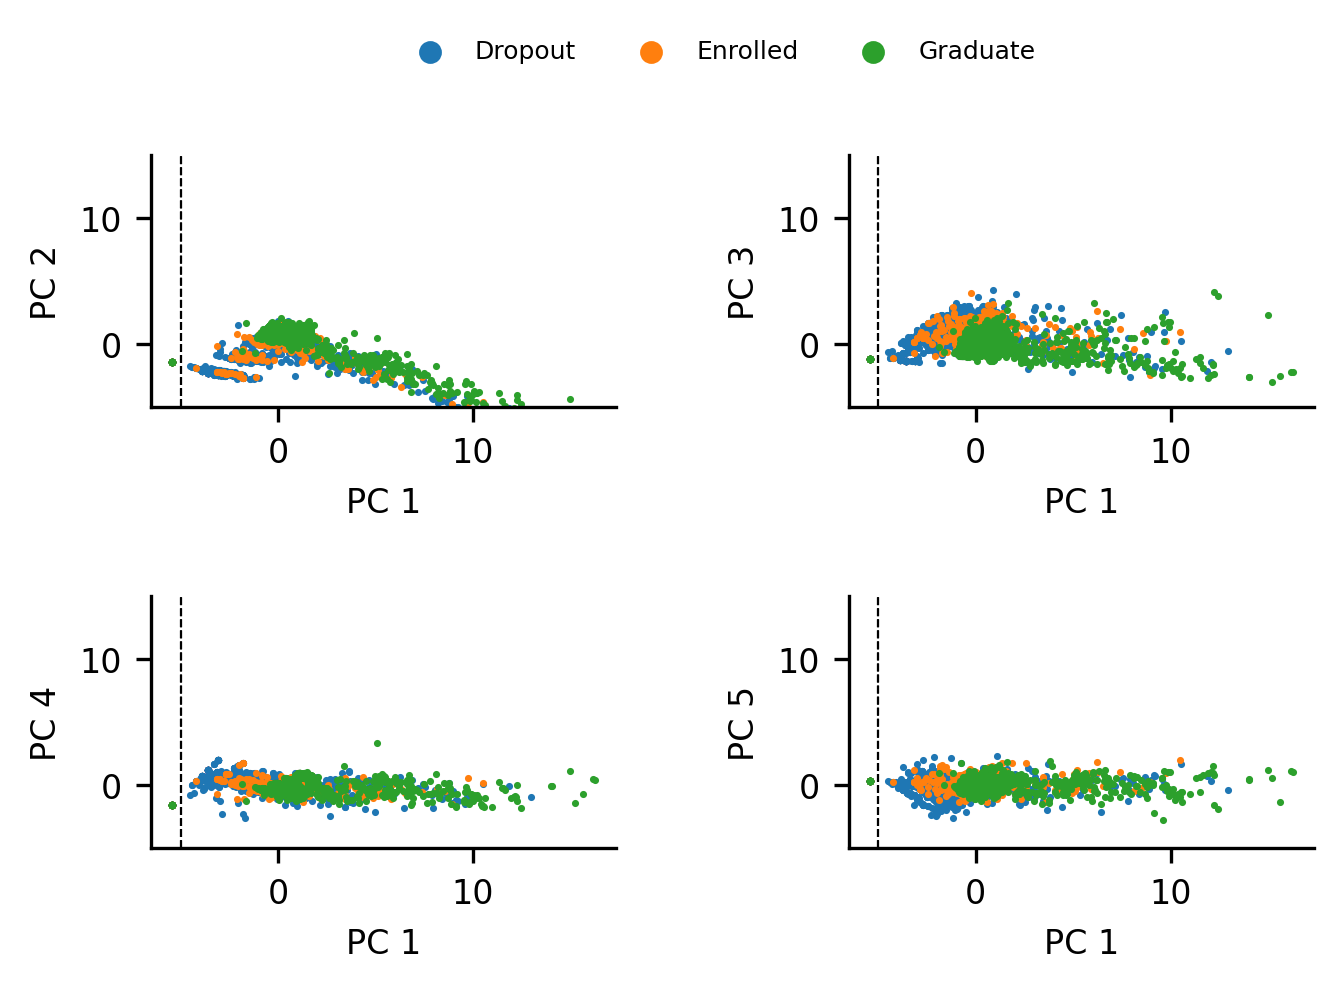

In [29]:
fig, ax = plt.subplots(2,2, figsize = (5,3))

fontsize = 8
categories = np.unique(Y.values)
labels = [np.where(Y.values[:,0] == categories[i])[0] for i in range(3)]
comp_pairs = (list(combinations(np.arange(10), 2)))
i = 0
for row in range(2):
    for col in range(2):
        for z, cat in enumerate(labels):
            ax[row, col].spines['top'].set_visible(False)
            ax[row, col].spines['right'].set_visible(False)
            ax[row, col].tick_params(labelsize = fontsize)

            c0, c1 = comp_pairs[i]
            ax[row, col].scatter(pca_transformed_x_3[cat,c0], pca_transformed_x_3[cat,c1], s = 0.5, label = np.unique(Y.values)[z]) 
            ax[row, col].set_xlabel(f"PC {c0+1}", fontsize = 8)
            ax[row, col].set_ylabel(f"PC {c1+1}", fontsize = 8)
            ax[row, col].plot([-5]*100, np.linspace(-5,15,100), '--', linewidth = 0.5, color = 'black')
            ax[row, col].set_ylim(-5,15)

        i+=1

fig.subplots_adjust(hspace = 0.75, wspace = .5)
lgnd = ax[0,0].legend(fontsize = 6, bbox_to_anchor = (1.95,1.55), frameon = False, ncol = 3)
for handle in lgnd.legend_handles:
    handle.set_sizes([20.0]) 

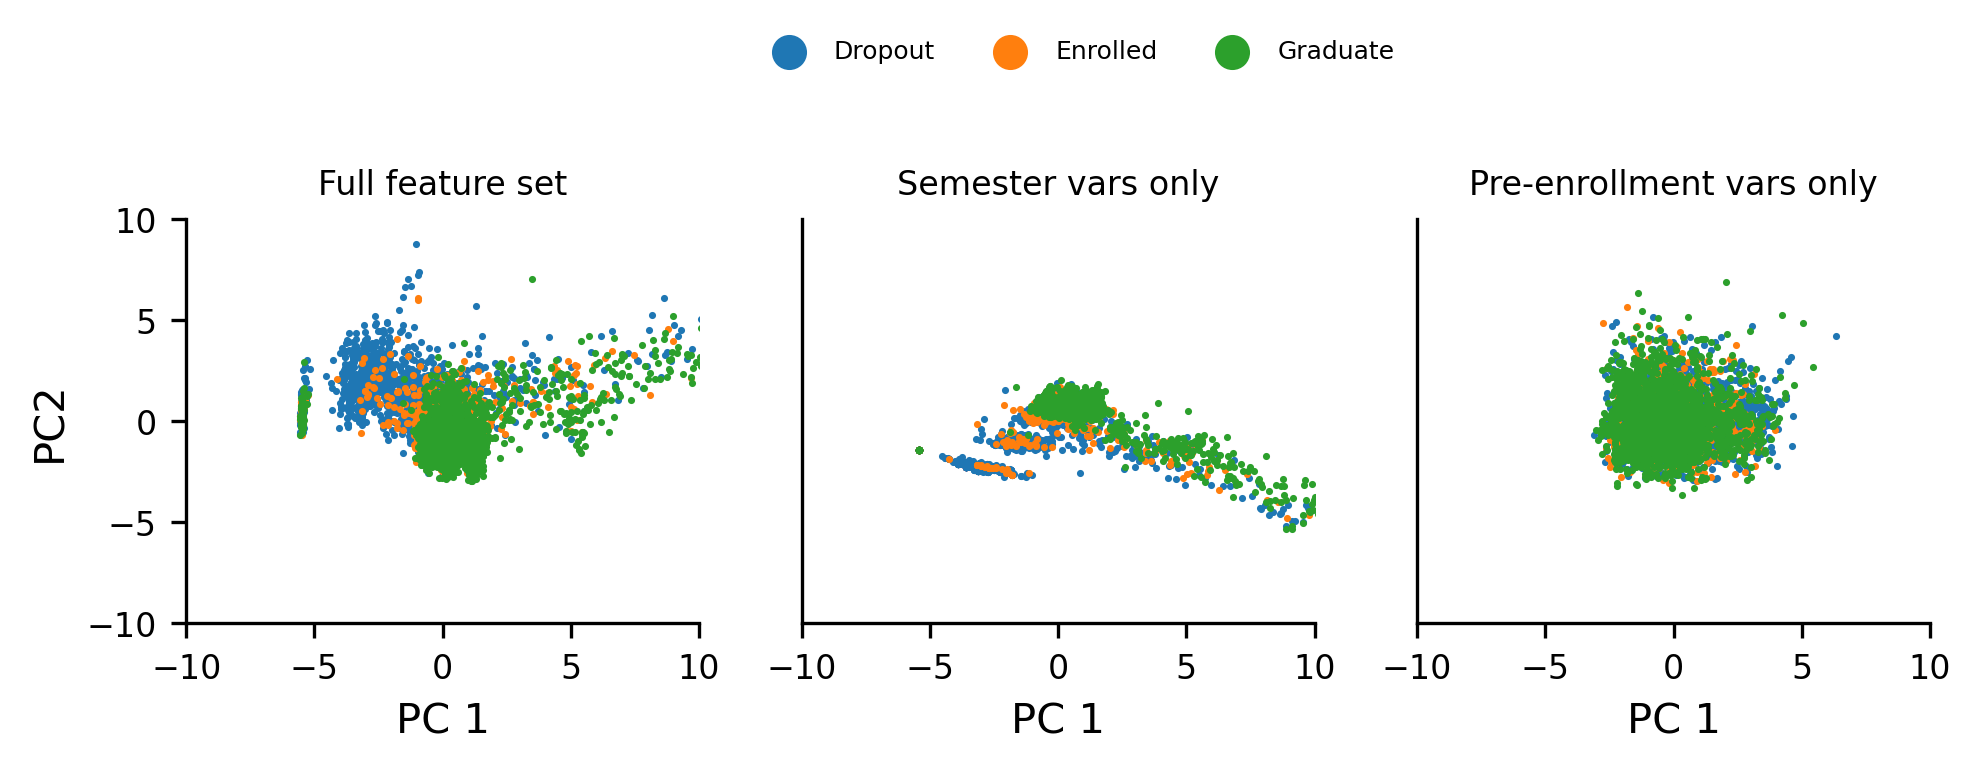

In [30]:
fig, ax = plt.subplots(1,3, figsize = (7.5,1.75))

for col in range(3):
    ax[col].spines['top'].set_visible(False)
    ax[col].spines['right'].set_visible(False)
    ax[col].tick_params(labelsize = fontsize)
    ax[col].set_ylim(-10,10)
    ax[col].set_xlim(-10,10)
    ax[col].set_xlabel("PC 1")
    if col>0:
        ax[col].set_yticks([])

for z, cat in enumerate(labels):
    ax[0].scatter(
        pca_transformed_x_1[cat, 0],
        pca_transformed_x_1[cat, 1],
        s = 0.5, label = np.unique(Y.values)[z]
    )

    ax[1].scatter(
        pca_transformed_x_3[cat, 0],
        pca_transformed_x_3[cat, 1],
        s = 0.5, label = np.unique(Y.values)[z]
    )

    ax[2].scatter(
        pca_transformed_x_2[cat, 0],
        pca_transformed_x_2[cat, 1],
        s = 0.5, label = np.unique(Y.values)[z]
    )
ax[0].set_ylabel("PC2")
ax[0].set_title("Full feature set", fontsize = 8)
ax[1].set_title("Semester vars only", fontsize = 8)
ax[2].set_title("Pre-enrollment vars only", fontsize = 8)
lgnd = ax[0].legend(fontsize = 6, bbox_to_anchor = (2.4,1.5), frameon = False, ncol = 3)
for handle in lgnd.legend_handles:
    handle.set_sizes([55.0]) 